# ✔️ 사전 세팅

In [ ]:
pip install torchinfo

In [ ]:
pip install ultralytics

In [ ]:
import os
import sys
import math
import glob
import random
import shutil
import warnings
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
from PIL import Image, ImageEnhance, ImageFilter

from tqdm import tqdm
from sklearn.metrics import average_precision_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_20newsgroups

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.utils.data.sampler import WeightedRandomSampler
import torchvision
import torchvision.models as models
import torchvision.transforms.functional as F2
import torchvision.transforms.v2 as v2
from torchvision import transforms
from torchvision.models.detection.ssd import SSD300_VGG16_Weights

from torchinfo import summary
from ultralytics import YOLO
import kagglehub

In [ ]:
# Warnings 제거
warnings.filterwarnings('ignore')

# Pandas 보기 옵션
pd.set_option('display.max_columns',100)

# Google drive 연결
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


---

# ✔️ 요약

본 실습에서는 같은 Oxford-IIIT Pet Dataset 데이터셋을 사용하여 <br>
**'SSD'와 'YOLO v8' 두 가지 방식으로 객체를 검출**해보았다. <br><br>

**SSD**는 이미지 데이터와 **XML 데이터**를 매칭하여 학습했지만, <br>
**YOLO**는 이미지 데이터와 **TXT 데이터**를 매칭하여 학습한다는 차이가 있었다. <br>
따라서 YOLO 실험에서는 XML을 TXT로 변환하는 과정을 추가했다.<br><br>

**SSD의 mAP는 0.9835**, **YOLO v8의 mAP는 0.9891**로 <br>
두 모델 모두 성능이 우수했고, 객체 검출도 잘 되었다.

---

# ✔️ **데이터 설명**

**1) 목적** <br>
본 프로젝트는 **SSD(Single Shot MultiBox Detector) 모델**을 활용하여<br>
**개와 고양이의 얼굴 영역을 탐지하는 객체 검출(Object Detection)** 모델 개발을 목표로 한다.<br>
이를 위해 데이터 전처리를 적용하고, 모델의 학습 및 성능 평가를 수행할 것이다.

<br>

**2) 데이터셋** <br>
본 프로젝트에서는 **Oxford-IIIT Pet Dataset 데이터셋**을 사용하며, <br>
데이터는 37종의 개와 고양이 이미지 파일, annotation으로 구성되어 있다.

---

# ✔️ **1) SSD 실험**

SSD 실험은 **데이터 분석 → 데이터 전처리 → SSD 모델 학습 및 평가** 순으로 진행된다.

## 🔗 **1 . 데이터 분석**

### **데이터 불러오기**

In [ ]:
# 초기화
if os.path.exists("/root/.cache/kagglehub/datasets/zippyz/cats-and-dogs-breeds-classification-oxford-dataset/"):
    shutil.rmtree("/root/.cache/kagglehub/datasets/zippyz/cats-and-dogs-breeds-classification-oxford-dataset/")

path = kagglehub.dataset_download("zippyz/cats-and-dogs-breeds-classification-oxford-dataset")
print("Dataset path:", path)

100%|██████████| 780M/780M [00:30<00:00, 26.7MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/zippyz/cats-and-dogs-breeds-classification-oxford-dataset/versions/1


### **데이터 개수 확인**

In [ ]:
trainval_file_path = os.path.join(path, "annotations", "annotations", "trainval.txt")
test_file_path = os.path.join(path, "annotations", "annotations", "test.txt")

image_dir = os.path.join(path, "images", "images")
xml_dir = os.path.join(path, "annotations", "annotations", "xmls")

# Train/Validation/Test 파일 읽기
df_trainval = pd.read_csv(trainval_file_path, sep="\s+", header=None)
df_test = pd.read_csv(test_file_path, sep="\s+", header=None)
df_trainval.columns = ["Image", "ClassID", "Species", "BreedID"]
df_test.columns = ["Image", "ClassID", "Species", "BreedID"]

print(f"Train/Validation 데이터 수: {len(df_trainval)}")
print(f"Test 데이터 수: {len(df_test)}")

# Annotation(XML) 개수 확인
xml_files = [file for file in os.listdir(xml_dir) if file.endswith(".xml")]
print(f"XML 파일 개수: {len(xml_files)}")

trainval_list = df_trainval['Image'].tolist()
test_list = df_test['Image'].tolist()

Train/Validation 데이터 수: 3680
Test 데이터 수: 3669
XML 파일 개수: 3686


Train/Validation 데이터 수와 XML 데이터의 개수가 동일해야 정상이다. <br>
그러나, 현재 데이터셋에는 **이미지 데이터와 XML 데이터의 짝이 안 맞는 것을 확인**할 수 있다. <br>
이는 추후 데이터 전처리 단계에서 처리할 예정이다.

### **데이터 종(Species) 확인**

Species가 1이면 고양이이고, 2이면 개이다.

Species
2    2492
1    1188
Name: count, dtype: int64


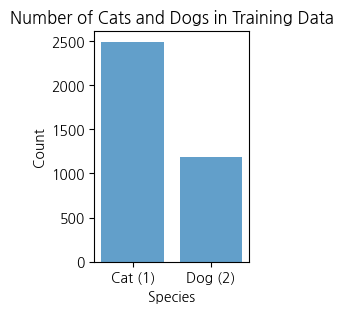

In [ ]:
species_counts = df_trainval['Species'].value_counts()
print(species_counts)

labels = ["Cat (1)", "Dog (2)"]

plt.figure(figsize=(2,3))
plt.bar(labels, species_counts, alpha=0.7)
plt.xlabel("Species")
plt.ylabel("Count")
plt.title("Number of Cats and Dogs in Training Data")
plt.show()

고양이 데이터의 개수는 1188개, 강아지 데이터의 개수는 2492개이다.

### **XML 구조 확인**

In [ ]:
example_xml_file = os.path.join(xml_dir, xml_files[0])

tree = ET.parse(example_xml_file)
root = tree.getroot()

def print_all_elements(element, indent=""):
    print(f"{indent}{element.tag}: {element.text}")
    for child in element:
        print_all_elements(child, indent + "  ")

print_all_elements(root)

annotation: None
  folder: OXIIIT
  filename: boxer_167.jpg
  source: None
    database: OXFORD-IIIT Pet Dataset
    annotation: OXIIIT
    image: flickr
  size: None
    width: 500
    height: 328
    depth: 3
  segmented: 0
  object: None
    name: dog
    pose: Frontal
    truncated: 0
    occluded: 0
    bndbox: None
      xmin: 37
      ymin: 26
      xmax: 286
      ymax: 292
    difficult: 0


XML 파일에는 **종, Bounding Box 좌표(얼굴 위치), pose** 등이 담겨있다. <br>
Bounding Box 정보를 나타내는 xmin, ymin, xmax, ymax는 추후 사용할 것이다.

### **데이터 샘플 확인**

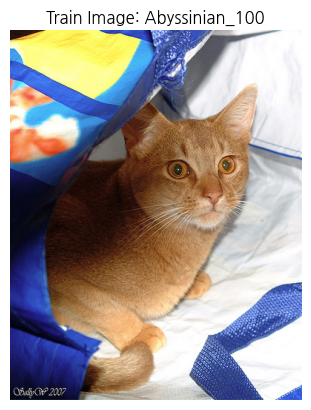

In [ ]:
train_example_image_name = df_trainval["Image"].iloc[0]
train_image_path = os.path.join(image_dir, f"{train_example_image_name}.jpg")

train_image = cv2.imread(train_image_path)
train_image = cv2.cvtColor(train_image, cv2.COLOR_BGR2RGB)

plt.imshow(train_image)
plt.title(f"Train Image: {train_example_image_name}")
plt.axis("off")
plt.show()

---

## 🔗 2. 데이터 전처리

### **XML이 없는 Train 이미지 제거**

In [ ]:
xml_list = [os.path.splitext(file)[0] for file in os.listdir(xml_dir) if file.endswith(".xml")]

# XML이 없는 train 이미지 목록
missing_xml = [image for image in trainval_list if image not in xml_list]
print(f"XML에 없는 Train 이미지 개수: {len(missing_xml)}")
print(missing_xml)

# train 이미지가 없는 XML 목록
extra_xml = [xml for xml in xml_list if xml not in trainval_list]
print(f"Train에 없는 XML 개수: {len(extra_xml)}")
print(extra_xml)

# 짝이 안 맞는 데이터는 drop
trainval_list = [image for image in trainval_list if image in xml_list]
xml_list = [xml for xml in xml_list if xml in trainval_list]

print("=====================================================")
print(f"최종 Train/Validation 데이터 수: {len(trainval_list)}")
print(f"최종 XML 파일 개수: {len(xml_list)}")

XML에 없는 Train 이미지 개수: 9
['Abyssinian_104', 'Bengal_111', 'samoyed_10', 'Bengal_175', 'Egyptian_Mau_14', 'Egyptian_Mau_156', 'Egyptian_Mau_186', 'Ragdoll_199', 'saint_bernard_15']
Train에 없는 XML 개수: 15
['english_cocker_spaniel_162', 'english_cocker_spaniel_179', 'Egyptian_Mau_129', 'english_cocker_spaniel_164', 'Bombay_190', 'newfoundland_155', 'newfoundland_152', 'Bombay_192', 'english_cocker_spaniel_163', 'newfoundland_153', 'Bombay_189', 'newfoundland_154', 'Siamese_203', 'Bombay_11', 'Egyptian_Mau_183']
최종 Train/Validation 데이터 수: 3671
최종 XML 파일 개수: 3671


1) XML(annotation)이 없는 Train 이미지<br>
2) train 이미지가 없는 XML 파일 <br>
위의 두 가지 경우는 불완전한 데이터라고 판단하여 drop했다.

### **객체 Bounding Box 리스트화**

모든 XML을 읽고, 이미지별 Bounding Box 정보를 하나의 리스트(annotations)에 저장했다.

In [ ]:
annotations = []

for xml_file in xml_files:
    xml_path = os.path.join(xml_dir, xml_file)
    tree = ET.parse(xml_path)
    root = tree.getroot()

    image_name = root.find("filename").text  # 이미지 파일 이름

    for obj in root.findall("object"):
        class_name = obj.find("name").text
        bndbox = obj.find("bndbox")
        x_min = int(bndbox.find("xmin").text)
        y_min = int(bndbox.find("ymin").text)
        x_max = int(bndbox.find("xmax").text)
        y_max = int(bndbox.find("ymax").text)

        annotations.append({
            "image": image_name,
            "class": class_name,
            "bbox": [x_min, y_min, x_max, y_max]
        })

지금까지 전처리가 잘 되었는지 예시 이미지를 시각화 해볼 것이다.

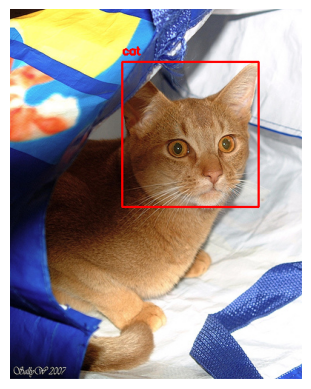

In [ ]:
# 0번 이미지 불러오기
train_example_image_name = df_trainval["Image"].iloc[0]
train_image_path = os.path.join(image_dir, f"{train_example_image_name}.jpg")

image = cv2.imread(train_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 0번 이미지의 XML 가져오기
annotations = [anno for anno in annotations if anno["image"] == f"{train_example_image_name}.jpg"]

# Bounding Box 그리기
for anno in annotations:
    x_min, y_min, x_max, y_max = anno["bbox"]
    cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)  # 빨간색 박스
    cv2.putText(image, anno["class"], (x_min, y_min - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

plt.imshow(image)
plt.axis("off")
plt.show()

---

### **데이터셋으로 변환**

In [ ]:
class VOCDataset(Dataset):
    def __init__(self, image_dir, annotation_dir, classes, image_list, transforms=None):
        self.image_dir = image_dir
        self.annotation_dir = annotation_dir
        self.classes = classes
        self.transforms = transforms
        self.image_files = image_list

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_file = self.image_files[idx] + ".jpg"
        annotation_file = self.image_files[idx] + ".xml"
        image_path = os.path.join(self.image_dir, image_file)
        annotation_path = os.path.join(self.annotation_dir, annotation_file)

        # 이미지 불러오기
        image = Image.open(image_path).convert("RGB")

        # 어노테이션 불러오기
        boxes = []
        labels = []
        tree = ET.parse(annotation_path)
        root = tree.getroot()

        for obj in root.findall("object"):
            class_name = obj.find("name").text
            if class_name not in self.classes:
                continue
            labels.append(self.classes.index(class_name))

            bndbox = obj.find("bndbox")
            x_min = int(bndbox.find("xmin").text)
            y_min = int(bndbox.find("ymin").text)
            x_max = int(bndbox.find("xmax").text)
            y_max = int(bndbox.find("ymax").text)
            boxes.append([x_min, y_min, x_max, y_max])

        # Tensor 변환
        if len(boxes) == 0:  # Bounding Box가 없는 경우
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        # Transform 적용
        if self.transforms:
            image, boxes, labels = self.transforms(image, boxes, labels)

        target = {"boxes": boxes, "labels": labels}
        return image, target

In [ ]:
class TestDataset(Dataset):
    def __init__(self, image_dir, image_list, transforms=None):
        self.image_dir = image_dir
        self.transforms = transforms
        self.image_files = image_list

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_file = self.image_files[idx] + ".jpg"
        image_path = os.path.join(self.image_dir, image_file)
        image = Image.open(image_path).convert("RGB")

        if self.transforms:
            image = self.transforms(image)

        return image, self.image_files[idx]

### **데이터 분할**

trainval_list는 **Train 80%, Validation 20%**으로 나눌 것이다.

In [ ]:
train_list, valid_list = train_test_split(trainval_list, test_size=0.3, random_state=42)

print(f"Train 이미지 수: {len(train_list)}")
print(f"Validation 이미지 수: {len(valid_list)}")
print(f"Test 이미지 수: {len(test_list)}")

Train 이미지 수: 2569
Validation 이미지 수: 1102
Test 이미지 수: 3669


### **데이터로더(DataLoader) 생성**

In [ ]:
class ResizeWithBoxes:
    def __init__(self, size):
        self.size = size

    def __call__(self, image, boxes, labels):
        orig_width, orig_height = image.size

        # 이미지 리사이즈
        image = F2.resize(image, self.size)

        # Bounding Box 비율 조정
        scale_x = self.size[1] / orig_width
        scale_y = self.size[0] / orig_height

        boxes[:, [0, 2]] *= scale_x
        boxes[:, [1, 3]] *= scale_y

        return image, boxes, labels

**Train과 Validation 데이터셋**에는 **Bounding Box도 같이 포함**되어 있기 때문에, <br>
Bounding Box가 없는 Test와 분리하여 전처리를 정의해주었다.

In [ ]:
# Train, Validation 전처리
train_transform = v2.Compose([
    ResizeWithBoxes((300, 300)),  # Bounding Box와 같이 변환
    v2.ToImage(),
    v2.ToDtype(dtype=torch.float32, scale=True),
    v2.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

# Test 전처리
test_transform = v2.Compose([
    v2.Resize((300, 300)),  # 이미지만 리사이즈
    v2.ToImage(),
    v2.ToDtype(dtype=torch.float32, scale=True),
    v2.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

In [ ]:
def collate_fn(batch):
    images, targets = zip(*batch)

    images = list(images)
    targets = list(targets)

    return images, targets

In [ ]:
# 클래스 정의
classes = ["background", "dog", "cat"]

# Train Dataset
train_dataset = VOCDataset(
    image_dir=image_dir,
    annotation_dir=xml_dir,
    classes=classes,
    image_list=train_list,
    transforms=train_transform
)

# Validation Dataset
valid_dataset = VOCDataset(
    image_dir=image_dir,
    annotation_dir=xml_dir,
    classes=classes,
    image_list=valid_list,
    transforms=train_transform
)

# Test Dataset
test_dataset = TestDataset(
    image_dir=image_dir,
    image_list=test_list,
    transforms=test_transform
)

# 데이터로더(DataLoader) 생성
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn, num_workers=2)
val_loader = DataLoader(valid_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn, num_workers=2)

---

## 🔗 3. SSD 모델

### **SSD 모델 준비**

In [ ]:
# SSD 모델 불러오기
model = torchvision.models.detection.ssd300_vgg16(weights=SSD300_VGG16_Weights.DEFAULT).to(device)

# 클래스 개수 정의
num_classes = len(classes)  # ["background", "dog", "cat"] = 3개

num_anchors = model.anchor_generator.num_anchors_per_location()

for i in range(len(model.head.classification_head.module_list)):
    in_channels = model.head.classification_head.module_list[i].in_channels
    model.head.classification_head.module_list[i] = nn.Conv2d(
        in_channels, num_classes * num_anchors[i], kernel_size=(3, 3), stride=1, padding=1
    )

for i in range(len(model.head.regression_head.module_list)):
    in_channels = model.head.regression_head.module_list[i].in_channels
    model.head.regression_head.module_list[i] = nn.Conv2d(
        in_channels, 4 * num_anchors[i], kernel_size=(3, 3), stride=1, padding=1
    )

model.num_classes = num_classes
model.head.num_classes = num_classes

model.head.classification_head.num_columns = num_classes

for i in range(len(model.head.classification_head.module_list)):
    model.head.classification_head.module_list[i].num_columns = num_classes

print(f"num_classes: {model.num_classes}")

num_classes: 3


기존 모델의 classification_head는 num_classes=81 (COCO 데이터셋 기준)이다. <br>
따라서 출력 레이어의 뉴런 개수를 81 → 3으로 바꿔주었다. <br>


### **SSD 모델 학습**

In [ ]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [ ]:
model = model.to(device)

# 손실값 저장
train_losses = []

# Training Loop
num_epochs = 5

for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1}/{num_epochs} 시작")

    model.train()
    total_train_loss = 0

    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        total_train_loss += losses.item()

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    print(f"Epoch {epoch + 1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}")

Epoch 1/5 시작


Epoch 1/5 - Training: 100%|██████████| 322/322 [01:33<00:00,  3.46it/s]


Epoch 1/5, Train Loss: 5.1211
Epoch 2/5 시작


Epoch 2/5 - Training: 100%|██████████| 322/322 [01:32<00:00,  3.47it/s]


Epoch 2/5, Train Loss: 3.0302
Epoch 3/5 시작


...

Epoch 3/5, Train Loss: 1.9806
Epoch 4/5 시작


Epoch 4/5 - Training: 100%|██████████| 322/322 [01:31<00:00,  3.53it/s]


Epoch 4/5, Train Loss: 1.5819
Epoch 5/5 시작


Epoch 5/5 - Training: 100%|██████████| 322/322 [01:31<00:00,  3.52it/s]

Epoch 5/5, Train Loss: 1.1342


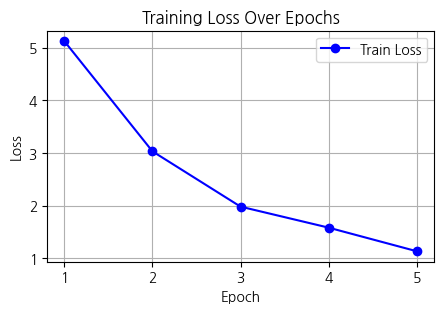

In [ ]:
plt.figure(figsize=(5,3))
plt.plot(range(1, num_epochs + 1), train_losses, marker="o", linestyle="-", color="b", label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.xticks(range(1, num_epochs + 1))
plt.legend()
plt.grid()
plt.show()

손실이 계속해서 감소하는 것을 확인할 수 있다.

### **SSD 모델 평가**

In [ ]:
# IoU 계산
def calculate_iou(box, boxes):
    x_min = np.maximum(box[0], boxes[:, 0])
    y_min = np.maximum(box[1], boxes[:, 1])
    x_max = np.minimum(box[2], boxes[:, 2])
    y_max = np.minimum(box[3], boxes[:, 3])

    intersection = np.maximum(0, x_max - x_min) * np.maximum(0, y_max - y_min)
    box_area = (box[2] - box[0]) * (box[3] - box[1])
    boxes_area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    union = box_area + boxes_area - intersection

    iou = intersection / (union + 1e-6)
    return iou

# IoU 기준으로  mAP 계산
def evaluate_model(predictions, ground_truths, classes, iou_threshold=0.5):
    class_aps = []

    for class_idx, class_name in enumerate(classes[1:], start=1):
        true_positives = []
        scores = []
        num_ground_truths = 0

        # 예측값과 정답값 비교
        for pred, gt in zip(predictions, ground_truths):
            pred_boxes = np.array(pred["boxes"].cpu().numpy()) if len(pred["boxes"]) > 0 else np.empty((0, 4))
            pred_scores = np.array(pred["scores"].cpu().numpy()) if len(pred["scores"]) > 0 else np.array([])
            gt_boxes = np.array(gt["boxes"].cpu().numpy()) if len(gt["boxes"]) > 0 else np.empty((0, 4))

            num_ground_truths += len(gt_boxes)

            if len(pred_boxes) == 0 or len(gt_boxes) == 0:
                continue

            # True Positive, False Positive 판단
            matched = np.zeros(len(gt_boxes), dtype=bool)
            for box, score in zip(pred_boxes, pred_scores):
                ious = calculate_iou(box, gt_boxes)
                max_iou_idx = np.argmax(ious) if len(ious) > 0 else -1
                max_iou = ious[max_iou_idx] if max_iou_idx >= 0 else 0

                if max_iou >= iou_threshold and not matched[max_iou_idx]:
                    true_positives.append(1)
                    matched[max_iou_idx] = True
                else:
                    true_positives.append(0)

                scores.append(score)

        if len(scores) == 0:
            class_aps.append(0)
            continue

        sorted_indices = np.argsort(-np.array(scores))
        true_positives = np.array(true_positives)[sorted_indices]
        scores = np.array(scores)[sorted_indices]

        cum_true_positives = np.cumsum(true_positives)
        precision = cum_true_positives / (np.arange(len(true_positives)) + 1)
        recall = cum_true_positives / num_ground_truths

        ap = average_precision_score(true_positives, scores) if len(scores) > 0 else 0
        class_aps.append(ap)

    mAP = np.mean(class_aps)
    return mAP

**IoU를 계산**하고, 이를 바탕으로 **mAP를 계산**하는 함수를 정의했다.

In [ ]:
model.eval()

val_predictions = []
val_ground_truths = []

# 성능 평가
with torch.no_grad():
    for images, targets in val_loader:
        images = [img.to(device) for img in images]
        predictions = model(images)  # 모델 추론

        # 예측 및 정답 저장
        val_predictions.extend(predictions)
        val_ground_truths.extend(targets)

# mAP 평가
val_mAP = evaluate_model(val_predictions, val_ground_truths, classes)
print(f"Validation mAP: {val_mAP:.4f}")

Validation mAP: 0.9835


**mAP는 0.9835**가 나왔다. <br>
이는 학습한 SSD 모델이 **거의 모든 객체를 정확하게 탐지**하고 있다는 것을 뜻한다.

### **SSD 모델 예측 및 결과**

In [ ]:
# 정규화 해제
def denormalize(image):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = image.permute(1, 2, 0).cpu().numpy()
    image = (image * std) + mean
    image = np.clip(image, 0, 1)

    return (image * 255).astype(np.uint8)

In [ ]:
model.eval()

num_samples = 8
sample_indices = random.sample(range(len(test_dataset)), num_samples)

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

with torch.no_grad():
    for i, idx in enumerate(sample_indices):
        image, image_name = test_dataset[idx]
        image_tensor = image.to(device).unsqueeze(0)

        # 모델 예측
        prediction = model(image_tensor)[0]

        # 정규화 해제 후 Bounding Box 그리기
        image_np = denormalize(image)
        for box, label, score in zip(prediction["boxes"], prediction["labels"], prediction["scores"]):
            if score > 0.5:  # 신뢰도 50% 이상만 시각화
                x_min, y_min, x_max, y_max = map(int, box.tolist())
                cv2.rectangle(image_np, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)
                cv2.putText(image_np, f"{classes[label]}: {score:.2f}", (x_min, y_min - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

        axes[i].imshow(image_np)
        axes[i].set_title(f"Image: {image_name}")
        axes[i].axis("off")

plt.suptitle("SSD Model Predictions on Test Images")
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

**개와 고양이를 높은 정확도**로 맞추고 있는 것을 확인할 수 있다.

---

# ✔️ **2) YOLO v8 실험**

YOLO v8 실험은 **데이터 분석 → 데이터 전처리 → YOLO 모델 학습 및 평가** 순으로 진행된다. <br>
처음에는 YOLO v1로 학습을 시도했지만, 너무 오래결려서 가장 최적화가 잘 된 v8로 바꿔 실험해보았다.

## 🔗 **1 . 데이터 분석**

### **데이터 불러오기**

In [ ]:
# 초기화
if os.path.exists("/root/.cache/kagglehub/datasets/zippyz/cats-and-dogs-breeds-classification-oxford-dataset/"):
    shutil.rmtree("/root/.cache/kagglehub/datasets/zippyz/cats-and-dogs-breeds-classification-oxford-dataset/")

path = kagglehub.dataset_download("zippyz/cats-and-dogs-breeds-classification-oxford-dataset")
print("Dataset path:", path)

# 경로 설정
image_dir = os.path.join(path, "images", "images")
xml_dir = os.path.join(path, "annotations", "annotations", "xmls")
yolo_label_dir = os.path.join(path, "labels")  # YOLO 라벨 저장 폴더

# YOLO 라벨 디렉토리 생성
os.makedirs(yolo_label_dir, exist_ok=True)

100%|██████████| 780M/780M [00:35<00:00, 23.1MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/zippyz/cats-and-dogs-breeds-classification-oxford-dataset/versions/1


### **데이터 개수 확인**

In [ ]:
# trainval.txt와 test.txt 경로
trainval_file_path = os.path.join(path, "annotations", "annotations", "trainval.txt")
test_file_path = os.path.join(path, "annotations", "annotations", "test.txt")

# Train/Validation/Test 데이터 읽기
df_trainval = pd.read_csv(trainval_file_path, sep="\s+", header=None)
df_test = pd.read_csv(test_file_path, sep="\s+", header=None)

df_trainval.columns = ["Image", "ClassID", "Species", "BreedID"]
df_test.columns = ["Image", "ClassID", "Species", "BreedID"]

print(f"Train/Validation 데이터 수: {len(df_trainval)}")
print(f"Test 데이터 수: {len(df_test)}")

Train/Validation 데이터 수: 3680
Test 데이터 수: 3669


데이터 분석은 SSD 실험에서 했기 때문에 바로 전처리로 넘어간다.

## 🔗 2. 데이터 전처리

### **XML을 YOLO TXT로 변환**

YOLO는 SSD와 달리, 어노테이션을 TXT 파일로 저장한다. <br>
따라서 **기존 XML 데이터를 TXT로 변환하여 저장**할 것이다.

In [ ]:
# XML → YOLO TXT 변환 함수
def convert_to_yolo(xml_file):
    import xml.etree.ElementTree as ET
    tree = ET.parse(xml_file)
    root = tree.getroot()

    image_filename = root.find("filename").text
    txt_filename = os.path.join(yolo_label_dir, os.path.splitext(image_filename)[0] + ".txt")

    size = root.find("size")
    img_w = int(size.find("width").text)
    img_h = int(size.find("height").text)

    with open(txt_filename, "w") as f:
        for obj in root.findall("object"):
            class_name = obj.find("name").text
            class_id = 0 if class_name == "dog" else 1

            bndbox = obj.find("bndbox")
            x_min = int(bndbox.find("xmin").text)
            y_min = int(bndbox.find("ymin").text)
            x_max = int(bndbox.find("xmax").text)
            y_max = int(bndbox.find("ymax").text)

            # YOLO 형식 변환 (정규화)
            x_center = (x_min + x_max) / 2.0 / img_w
            y_center = (y_min + y_max) / 2.0 / img_h
            width = (x_max - x_min) / img_w
            height = (y_max - y_min) / img_h

            f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

# trainval.txt 기반으로 변환할 XML 리스트 필터링
trainval_list = df_trainval['Image'].tolist()
xml_files = [os.path.join(xml_dir, file) for file in os.listdir(xml_dir) if file.endswith(".xml")]
xml_files = [file for file in xml_files if os.path.splitext(os.path.basename(file))[0] in trainval_list]

# 변환
for xml_file in xml_files:
    convert_to_yolo(xml_file)

print(f"{len(xml_files)}개 XML 파일 변환 완료")

3671개 XML 파일 변환 완료


Train/Validation 데이터 수는 3680개인데, 변환한 XML 파일 개수는 3671개이다. <br>
이는 XML 파일이 없는 이미지가 9개라는 뜻이다. <br>
추후 XML 파일이 없는 Train/Validation 데이터는 drop할 예정이다.

### **TXT 구조 확인**

In [ ]:
sample_txt = os.path.join(yolo_label_dir, random.choice(os.listdir(yolo_label_dir)))

print(f"YOLO 라벨 파일 예시: \n")
with open(sample_txt, "r") as f:
    lines = f.readlines()
    for line in lines:
        print(line.strip())

YOLO 라벨 파일 예시: 

1 0.258333 0.204167 0.308333 0.358333


TXT 파일은 XMl 파일과 다르게 <br>
```<class_id> <x_center> <y_center> <width> <height>```
형식으로 저장된다.

### **XML이 없는 Train 이미지 제거**

In [ ]:
image_list = [file for file in os.listdir(image_dir) if file.endswith(".jpg")]
image_list = [os.path.splitext(file)[0] for file in image_list if os.path.splitext(file)[0] in trainval_list]

# YOLO TXT 파일 리스트 가져오기
txt_list = [os.path.splitext(file)[0] for file in os.listdir(yolo_label_dir) if file.endswith(".txt")]

# TXT가 없는 train 이미지 목록
missing_txt = [img for img in image_list if img not in txt_list]
print(f"YOLO(TXT) 없는 Train/Validation 이미지 개수: {len(missing_txt)}")
print("일부 샘플:", missing_txt)

# train 이미지가 없는 TXT 목록
extra_txt = [txt for txt in txt_list if txt not in image_list]
print(f"이미지 없는 YOLO(TXT) 개수: {len(extra_txt)}")
print("일부 샘플:", extra_txt)

# 짝이 안 맞는 데이터는 drop
final_image_list = [img for img in image_list if img in txt_list]
final_txt_list = [txt for txt in txt_list if txt in image_list]

print("=====================================================")
print(f"최종 Train/Validation 데이터 수: {len(final_image_list)}")
print(f"최종 YOLO(TXT) 파일 개수: {len(final_txt_list)}")

YOLO(TXT) 없는 Train/Validation 이미지 개수: 9
일부 샘플: ['Egyptian_Mau_156', 'saint_bernard_15', 'Ragdoll_199', 'Egyptian_Mau_14', 'Bengal_111', 'Bengal_175', 'Abyssinian_104', 'Egyptian_Mau_186', 'samoyed_10']
이미지 없는 YOLO(TXT) 개수: 0
일부 샘플: []
최종 Train/Validation 데이터 수: 3671
최종 YOLO(TXT) 파일 개수: 3671


### **데이터 분할**

final_image_list는 Train 80%, Validation 20%으로 나눌 것이다.

In [ ]:
train_list, valid_list = train_test_split(final_image_list, test_size=0.2, random_state=42)

print(f"Train 데이터셋 크기: {len(train_list)}")
print(f"Validation 데이터셋 크기: {len(valid_list)}")

Train 데이터셋 크기: 2936
Validation 데이터셋 크기: 735


### **데이터셋으로 변환**

In [ ]:
yolo_dataset_path = "yolo_dataset"
os.makedirs(yolo_dataset_path, exist_ok=True)

for split, data_list in zip(["train", "val"], [train_list, valid_list]):
    img_split_path = os.path.join(yolo_dataset_path, "images", split)
    lbl_split_path = os.path.join(yolo_dataset_path, "labels", split)
    os.makedirs(img_split_path, exist_ok=True)
    os.makedirs(lbl_split_path, exist_ok=True)

    for img_file in data_list:
        img_src = os.path.join(image_dir, img_file + ".jpg")
        lbl_src = os.path.join(yolo_label_dir, img_file + ".txt")

        img_dst = os.path.join(img_split_path, img_file + ".jpg")
        lbl_dst = os.path.join(lbl_split_path, img_file + ".txt")

        shutil.copy(img_src, img_dst)
        shutil.copy(lbl_src, lbl_dst)

print("YOLOv8 데이터셋 준비 완료")

YOLOv8 데이터셋 준비 완료


### **데이터 샘플 확인**

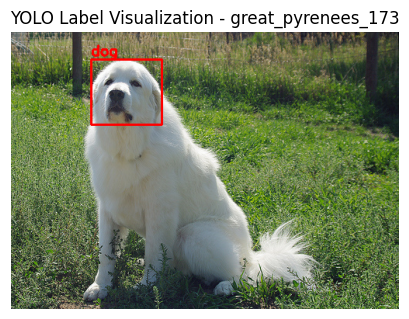

In [ ]:
classes = ["dog", "cat"]

# 랜덤 이미지 선택
random_img = random.choice(train_list)
img_path = os.path.join(image_dir, random_img + ".jpg")
label_path = os.path.join(yolo_label_dir, random_img + ".txt")

# 이미지 로드
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
img_h, img_w, _ = image.shape

# YOLO 라벨(TXT) 로드
if os.path.exists(label_path):
    with open(label_path, "r") as f:
        labels = f.readlines()
else:
    labels = []

# Bounding Box 그리기
for label in labels:
    data = label.strip().split()
    class_id = int(data[0])
    x_center, y_center, width, height = map(float, data[1:])

    # 정규화된 좌표를 원래 이미지 크기로 변환
    x_min = int((x_center - width / 2) * img_w)
    y_min = int((y_center - height / 2) * img_h)
    x_max = int((x_center + width / 2) * img_w)
    y_max = int((y_center + height / 2) * img_h)

    color = (255, 0, 0)
    cv2.rectangle(image, (x_min, y_min), (x_max, y_max), color, 2)
    cv2.putText(image, classes[class_id], (x_min, y_min - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

# 시각화
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.title(f"YOLO Label Visualization - {random_img}")
plt.show()

---

## 🔗 3. YOLO 모델

### **YOLO 모델 준비**

In [ ]:
# YOLO v8 모델 불러오기
model = YOLO("yolov8s.pt")

### **YOLO 모델 학습**

YOLO 모델이 **데이터 위치와 클래스 정보를 인식**할 수 있도록 <br>
**yml 파일**에 경로를 작성해두었다.

In [ ]:
dataset_yaml_path = "/content/yolo_dataset/dataset.yaml"

yaml_content =f"""
path: /content/yolo_dataset
train: images/train
val: images/val

names:
  0: dog
  1: cat
"""

# 파일 저장
with open(dataset_yaml_path, "w") as f:
    f.write(yaml_content)

print("dataset.yaml 파일 생성 완료")

dataset.yaml 파일 생성 완료


**Ultralytics YOLO 라이브러리**를 사용하여 <br>
손실 함수 계산부터 역전파까지 **모델 학습을 자동으로 처리**했다.

In [ ]:
model.train(
    data="/content/yolo_dataset/dataset.yaml",
    epochs=5,
    imgsz=640,
    batch=8,
    save_period=1,  # 매 epoch마다 모델 저장
    device="cuda" if torch.cuda.is_available() else "cpu"
)

Ultralytics 8.3.82 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/yolo_dataset/dataset.yaml, epochs=5, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=1, cache=False, device=cuda, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show

train: Scanning /content/yolo_dataset/labels/train... 2936 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2936/2936 [00:01<00:00, 1945.85it/s]

train: WARNING ⚠️ /content/yolo_dataset/images/train/Egyptian_Mau_138.jpg: corrupt JPEG restored and saved


train: New cache created: /content/yolo_dataset/labels/train.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Scanning /content/yolo_dataset/labels/val... 735 images, 0 backgrounds, 0 corrupt: 100%|██████████| 735/735 [00:00<00:00, 1055.72it/s]

...

                   all        735        735      0.979      0.953      0.989      0.829



5 epochs completed in 0.110 hours.
Optimizer stripped from runs/detect/train2/weights/last.pt, 22.5MB
Optimizer stripped from runs/detect/train2/weights/best.pt, 22.5MB

Validating runs/detect/train2/weights/best.pt...
Ultralytics 8.3.82 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 46/46 [00:07<00:00,  6.27it/s]


                   all        735        735      0.979      0.953      0.989       0.83
                   dog        487        487      0.962      0.943      0.985      0.765
                   cat        248        248      0.995      0.964      0.993      0.894
Speed: 0.2ms preprocess, 3.3ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs/detect/train2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e1146515690>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

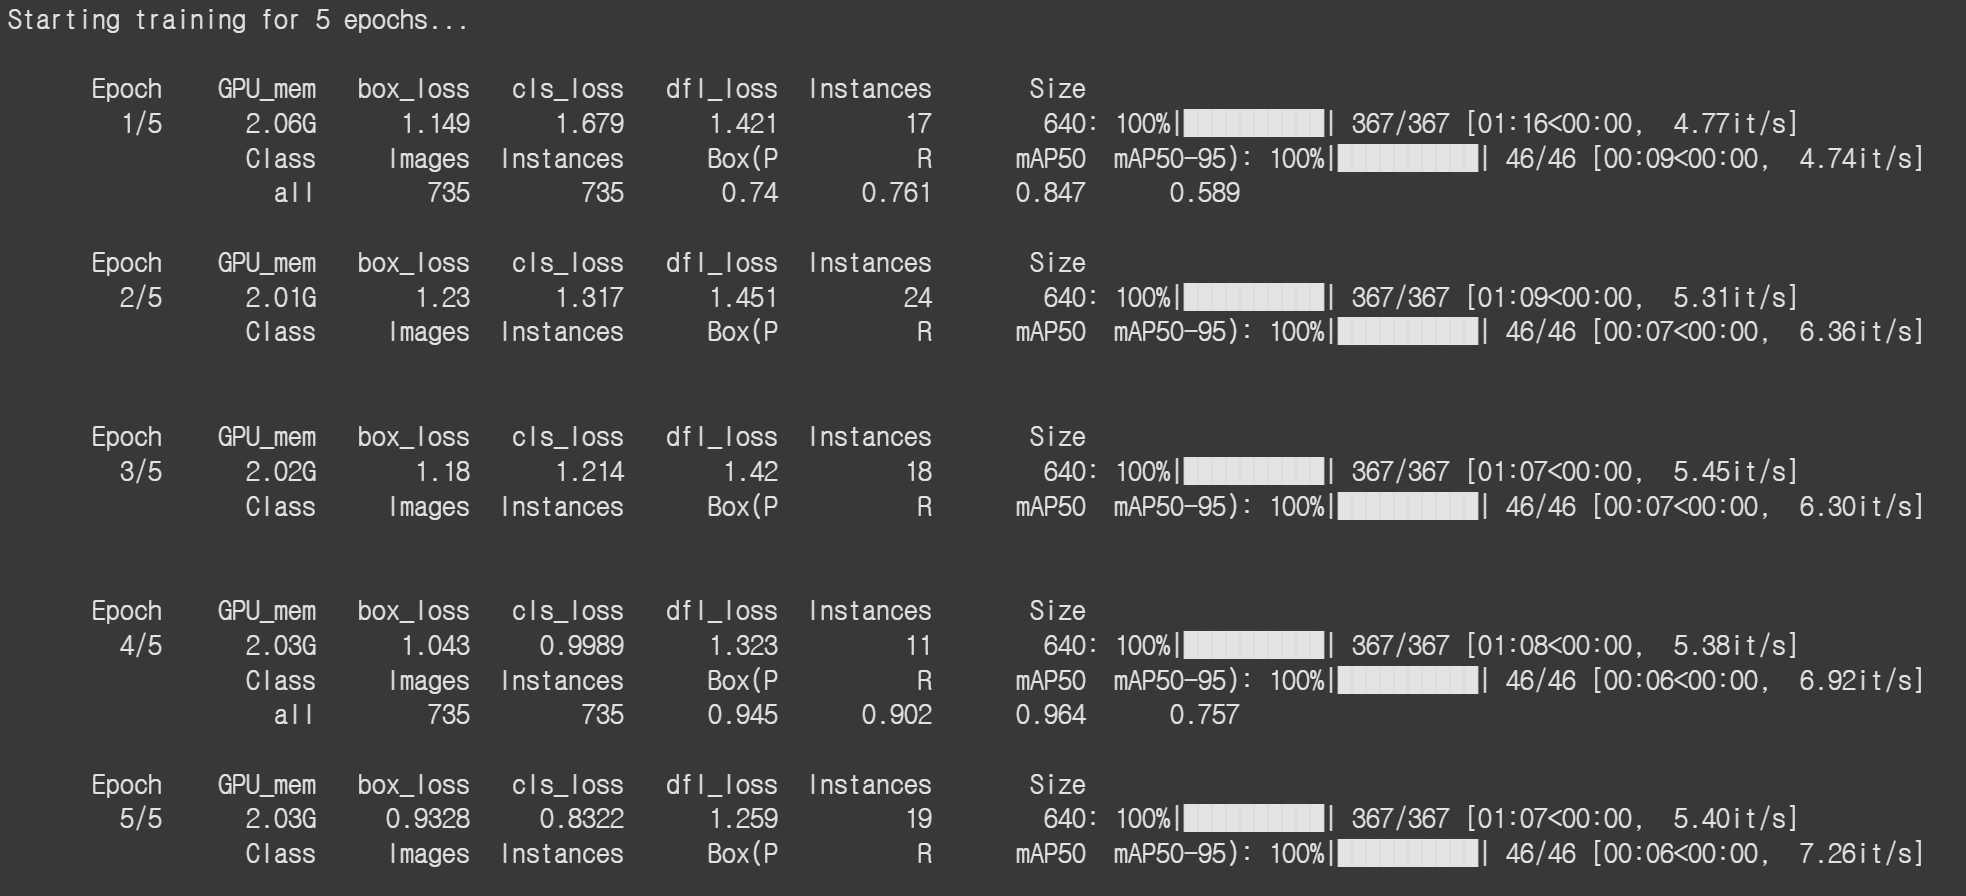

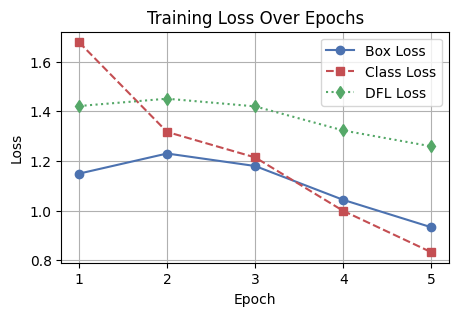

In [ ]:
log_path = "/content/runs/detect/train2/results.csv"

# CSV 파일 읽기
df = pd.read_csv(log_path)

# 손실값 시각화
plt.figure(figsize=(5, 3))
plt.plot(df["epoch"], df["train/box_loss"], marker="o", linestyle="-", color="b", label="Box Loss")
plt.plot(df["epoch"], df["train/cls_loss"], marker="s", linestyle="--", color="r", label="Class Loss")
plt.plot(df["epoch"], df["train/dfl_loss"], marker="d", linestyle=":", color="g", label="DFL Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.xticks(df["epoch"])
plt.legend()
plt.grid()
plt.show()

손실이 계속해서 감소하는 것을 확인할 수 있다.

### **YOLO 모델 평가**

In [ ]:
metrics = model.val()
print(f"mAP@50: {metrics.box.map50:.4f}")

Ultralytics 8.3.82 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)


val: Scanning /content/yolo_dataset/labels/val.cache... 735 images, 0 backgrounds, 0 corrupt: 100%|██████████| 735/735 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 46/46 [00:10<00:00,  4.31it/s]


                   all        735        735      0.978      0.952      0.989      0.829
                   dog        487        487       0.96      0.941      0.985      0.765
                   cat        248        248      0.995      0.964      0.993      0.894
Speed: 0.9ms preprocess, 6.6ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs/detect/val
mAP@50: 0.9891


**mAP는 0.9891**이 나왔다. <br>
이는 학습한 YOLO v8 모델이 거의 모든 객체를 정확하게 탐지하고 있다는 것을 뜻한다. <br>
**앞서 학습한 SSD 모델의 mAP와 큰 차이는 없다.**

### **YOLO 모델 예측 및 시각화**

In [ ]:
# test 데이터셋 만들기
test_list = df_test["Image"].tolist()

# test 폴더 생성
test_img_path = os.path.join(yolo_dataset_path, "images", "test")
test_lbl_path = os.path.join(yolo_dataset_path, "labels", "test")
os.makedirs(test_img_path, exist_ok=True)
os.makedirs(test_lbl_path, exist_ok=True)

# 이미지와 TXT 복사
for img_file in test_list:
    img_src = os.path.join(image_dir, img_file + ".jpg")
    lbl_src = os.path.join(yolo_label_dir, img_file + ".txt")

    img_dst = os.path.join(test_img_path, img_file + ".jpg")
    lbl_dst = os.path.join(test_lbl_path, img_file + ".txt")

    if os.path.exists(img_src):
        shutil.copy(img_src, img_dst)
    if os.path.exists(lbl_src):
        shutil.copy(lbl_src, lbl_dst)

print(f"Test 데이터셋 생성 완료 / 총 {len(test_list)}개 이미지")

Test 데이터셋 생성 완료 / 총 3669개 이미지


In [ ]:
dataset_yaml_path = "/content/yolo_dataset/dataset.yaml"

yaml_content =f"""
path: /content/yolo_dataset
train: images/train
val: images/val
test: images/test

names:
  0: dog
  1: cat
"""

# 파일 덮어쓰기
with open(dataset_yaml_path, "w") as f:
    f.write(yaml_content)

print("dataset.yaml 파일 수정 완료")

dataset.yaml 파일 수정 완료


In [ ]:
model_path = "/content/runs/detect/train2/weights/best.pt"
model = YOLO(model_path)
print("학습된 모델 로드 완료")

# 랜덤 8개 선택
test_image_dir = "yolo_dataset/images/test"
test_images = [img for img in os.listdir(test_image_dir) if img.endswith(".jpg")]
sample_images = random.sample(test_images, 8)

# 시각화
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, img_name in enumerate(sample_images):
    img_path = f"{test_image_dir}/{img_name}"

    # 이미지 로드
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_h, img_w, _ = image.shape

    # YOLOv8 예측
    results = model.predict(source=img_path, conf=0.5, verbose=False)  # 신뢰도 50% 이상 예측

    # Bounding Box 시각화
    for result in results:
        for box in result.boxes:
            x_min, y_min, x_max, y_max = map(int, box.xyxy[0].tolist())
            score = box.conf[0].item()
            class_id = int(box.cls[0].item())

            color = (255, 0, 0)
            cv2.rectangle(image, (x_min, y_min), (x_max, y_max), color, 2)
            cv2.putText(image, f"{model.names[class_id]}: {score:.2f}", (x_min, y_min - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    axes[i].imshow(image)
    axes[i].set_title(f"Image: {img_name}")
    axes[i].axis("off")

plt.suptitle("YOLOv8 Predictions on Test Images")
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

**개와 고양이를 높은 정확도**로 맞추고 있는 것을 확인할 수 있다.

---